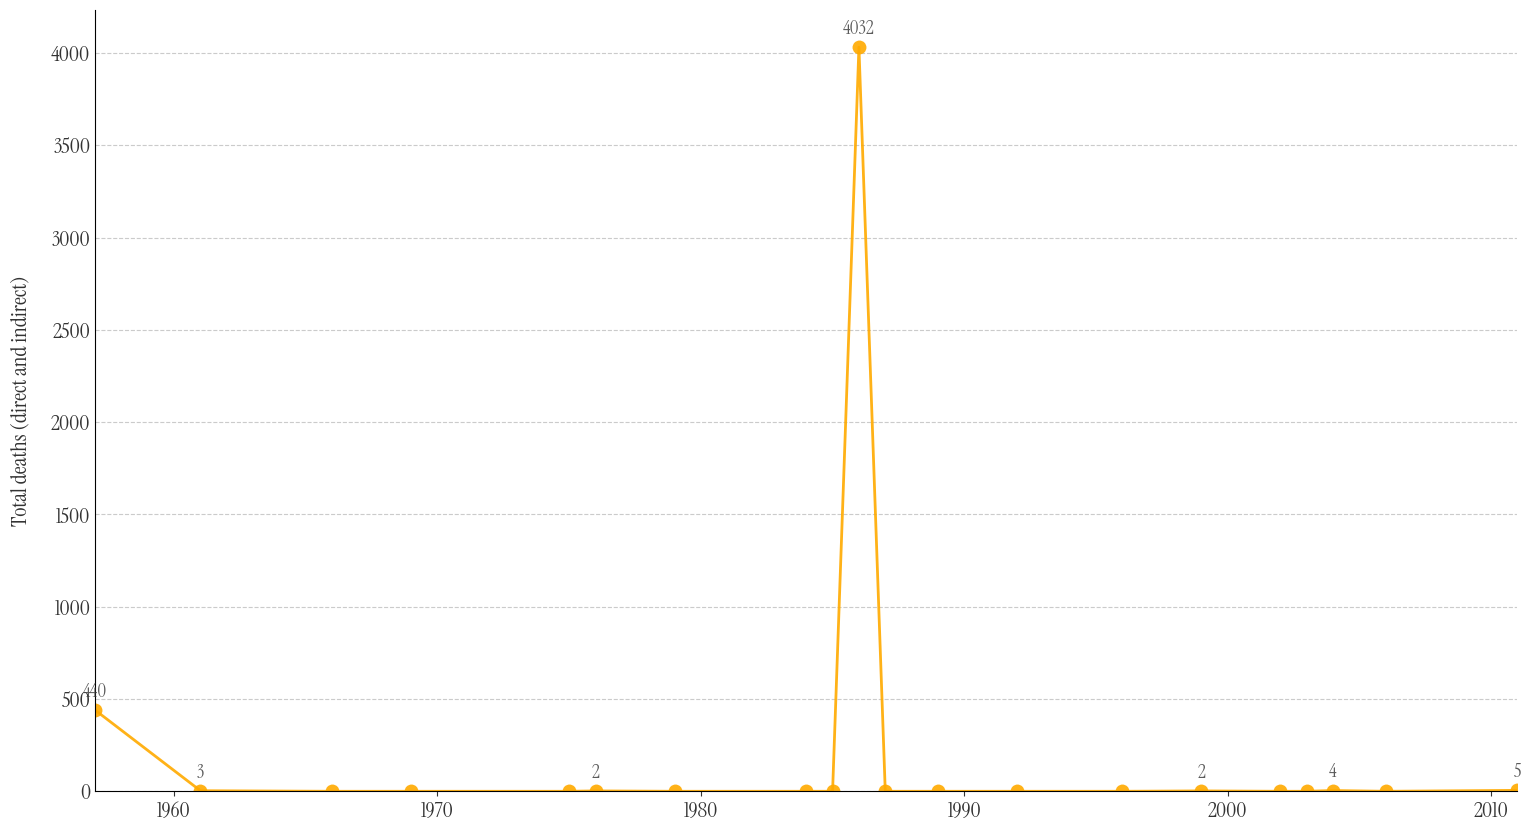

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from dotenv import load_dotenv
import os

# -----------------------------
# 1. Load data
# -----------------------------
df = pd.read_csv("./data/Nuclear_Incidents_-_Sheet3.csv")

# Clean column names
df.columns = (
    df.columns
      .str.replace(" ", "", regex=False)
      .str.replace("\n", "", regex=False)
      .str.strip()
)

# Clean death columns
df["NumbersofInDirectDeaths"] = (
    df["NumbersofInDirectDeaths"]
    .fillna("0")
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["NumbersofDirectDeaths"] = (
    pd.to_numeric(df["NumbersofDirectDeaths"], errors="coerce")
    .fillna(0)
)

df["Total_Deaths"] = (
    df["NumbersofDirectDeaths"] + df["NumbersofInDirectDeaths"]
)

# Parse year
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")
df["Year"] = df["Date"].dt.year.astype("Int64")

# Aggregate by year
df_yearly = (
    df.groupby("Year", dropna=True)["Total_Deaths"]
      .sum()
      .reset_index()
      .sort_values("Year")
)

# -----------------------------
# 2. Font setup
# -----------------------------
FONT_PATH = "./font.ttf"
fm.fontManager.addfont(FONT_PATH)
font_prop = fm.FontProperties(fname=FONT_PATH)
FONT_NAME = font_prop.get_name()

# -----------------------------
# 3. Colors
# -----------------------------
load_dotenv("colors.env")

LINE_COLOR = os.getenv("NUCLEAR")
BLACK = os.getenv("BLACK")
WHITE = os.getenv("WHITE")

# -----------------------------
# 4. Global style (MATCHED)
# -----------------------------
plt.rcParams.update({
    "font.family": FONT_NAME,
    "font.size": 16,

    "text.color": BLACK,
    "axes.labelcolor": BLACK,
    "xtick.color": BLACK,
    "ytick.color": BLACK,

    "figure.facecolor": "none",
    "axes.facecolor": "none",

    "axes.spines.top": False,
    "axes.spines.right": False,

    "grid.color": BLACK,
    "grid.linestyle": "--",
    "grid.alpha": 0.25,
})

# -----------------------------
# 5. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 9))

ax.plot(
    df_yearly["Year"],
    df_yearly["Total_Deaths"],
    color=LINE_COLOR,
    linewidth=2,
    alpha=0.9,

    marker="o",
    markersize=10,
    markerfacecolor=LINE_COLOR,
    markeredgecolor="none",
    markeredgewidth=0.5
)

for x, y in zip(df_yearly["Year"], df_yearly["Total_Deaths"]):
    if y == 0:
        continue

    ax.text(
        x,
        y + 50,
        f"{int(y)}",
        ha="center",
        va="bottom",
        fontsize=14,        # secondary info
        color=BLACK,
        alpha=0.8
    )

# -----------------------------
# 6. Axes & labels (MATCHED)
# -----------------------------
ax.set_ylabel("Total deaths (direct and indirect)", fontsize=16, labelpad=15)

ax.tick_params(axis="both", labelsize=16)
ax.tick_params(axis="y", length=0)

ax.grid(True, axis="y")
ax.set_axisbelow(True)

ax.set_ylim(bottom=0)
ax.set_xlim(df_yearly["Year"].min(), df_yearly["Year"].max())

# Integer years on x-axis
ax.xaxis.get_major_locator().set_params(integer=True)

# -----------------------------
# 7. Export (MATCHED)
# -----------------------------
plt.tight_layout(pad=2)
plt.savefig(
    "./nuclear_incidents_deaths_by_year.svg",
    format="svg",
    bbox_inches="tight",
    transparent=True
)
plt.show()
